In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [2]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC
from circuits import CPCircuit

In [3]:
train = pd.read_csv("DailyDelhiClimateTrain.csv",parse_dates=["date"], index_col="date").sort_index(inplace=False)
test = pd.read_csv("DailyDelhiClimateTest.csv",parse_dates=["date"], index_col="date").sort_index(inplace=False)

In [4]:
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler((0,1))
train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

In [6]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])
    return np.array(X), np.array(y)

In [7]:
def create_test_sequences(train_tail, test_data, seq_length):
    full = np.concatenate([train_tail[-seq_length:], test_data], axis=0)
    X = []
    for i in range(len(test_data)):
        X.append(full[i:i+seq_length])
    return np.array(X)

In [8]:
SEQ_LEN = 5
X_train_, y_train = create_sequences(train_scaled, SEQ_LEN)

In [9]:
X_test_ = create_test_sequences(train_scaled, test_scaled, SEQ_LEN)
X_train__ = X_train_.reshape((X_train_.shape[0], SEQ_LEN, len(features)))
X_test__ = X_test_.reshape((X_test_.shape[0], SEQ_LEN, len(features)))

y_test = test_scaled[:, 0]  # Column 0 = meantemp
y_test = y_test[:X_test__.shape[0]]

In [10]:
X_train = [sample.flatten() for sample in X_train__]
X_test = [sample.flatten() for sample in X_test__]

In [11]:
X_train[1]

array([0.04279476, 0.90759076, 0.07058266, 0.132881  , 0.0356623 ,
       0.84983498, 0.10974262, 0.13299381, 0.08151383, 0.66886689,
       0.02921206, 0.13279856, 0.        , 0.84790979, 0.08763619,
       0.13271178, 0.03056769, 0.80132013, 0.03505448, 0.13290703])

In [12]:
window_size = SEQ_LEN*4

In [18]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm

results = []

# RC Hyperparameters
rc_param_grid = {
    'reservoir_size': [100, 150, 300],
    'spectral_radius': [0.4, 0.6, 0.9],
    'sparsity': [0.05, 0.1, 0.2],
    'model_type': ['ridge'],
    # 'ridge_alpha': [1e-3, 1e-2, 1e-1]  # Only if your CRM.train uses this
}


In [19]:
best_rc_score = float('inf')
best_rc_params = None
                   
for params in tqdm(ParameterGrid(rc_param_grid), desc="Tuning RC"):
    CRM = ClassicalRC(
        input_size=window_size,
        reservoir_size=params['reservoir_size'],
        spectral_radius=params['spectral_radius'],
        sparsity=params['sparsity'],
        use_reservoir=True
    )

    try:
        CRM.train(X_train, y_train, model_type=params['model_type'], alpha=params['ridge_alpha'])
        y_pred = CRM.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)

        results.append({'model': 'ClassicalRC', 'params': params, 'mse': mse})
        if mse < best_rc_score:
            best_rc_score = mse
            best_rc_params = params
    except Exception as e:
        print("Error with RC params:", params, "→", e)


Tuning RC:  30%|█████████▊                       | 8/27 [00:00<00:00, 78.88it/s]

Error with RC params: {'model_type': 'ridge', 'reservoir_size': 100, 'sparsity': 0.05, 'spectral_radius': 0.4} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 100, 'sparsity': 0.05, 'spectral_radius': 0.6} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 100, 'sparsity': 0.05, 'spectral_radius': 0.9} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 100, 'sparsity': 0.1, 'spectral_radius': 0.4} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 100, 'sparsity': 0.1, 'spectral_radius': 0.6} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 100, 'sparsity': 0.1, 'spectral_radius': 0.9} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 100, 'sparsity': 0.2, 'spectral_radius': 0.4} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 100, 'sparsity': 0.2, 'spectral_radius': 0.6} → 'ri

Tuning RC:  59%|██████████████████▉             | 16/27 [00:00<00:00, 33.68it/s]

Error with RC params: {'model_type': 'ridge', 'reservoir_size': 150, 'sparsity': 0.2, 'spectral_radius': 0.6} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 150, 'sparsity': 0.2, 'spectral_radius': 0.9} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.05, 'spectral_radius': 0.4} → 'ridge_alpha'


Tuning RC:  78%|████████████████████████▉       | 21/27 [00:00<00:00, 18.53it/s]

Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.05, 'spectral_radius': 0.6} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.05, 'spectral_radius': 0.9} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.1, 'spectral_radius': 0.4} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.1, 'spectral_radius': 0.6} → 'ridge_alpha'


Tuning RC:  89%|████████████████████████████▍   | 24/27 [00:01<00:00, 13.28it/s]

Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.1, 'spectral_radius': 0.9} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.2, 'spectral_radius': 0.4} → 'ridge_alpha'
Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.2, 'spectral_radius': 0.6} → 'ridge_alpha'


Tuning RC: 100%|████████████████████████████████| 27/27 [00:01<00:00, 13.62it/s]

Error with RC params: {'model_type': 'ridge', 'reservoir_size': 300, 'sparsity': 0.2, 'spectral_radius': 0.9} → 'ridge_alpha'


In [15]:
# Ridge
ridge_grid = {'alpha': [1e-3, 1e-2, 1e-1, 1]}
for params in ParameterGrid(ridge_grid):
    model = Ridge(**params)
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))
    results.append({'model': 'Ridge', 'params': params, 'mse': mse})

# Linear Regression (no HPO needed)
model = LinearRegression()
model.fit(X_train, y_train)
mse = mean_squared_error(y_test, model.predict(X_test))
results.append({'model': 'LinearRegression', 'params': {}, 'mse': mse})

# MLP
mlp_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3]
}
for params in ParameterGrid(mlp_grid):
    model = MLPRegressor(max_iter=500, random_state=42, **params)
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))
    results.append({'model': 'MLP', 'params': params, 'mse': mse})


In [16]:
df_results = pd.DataFrame(results)
df_results['rmse'] = np.sqrt(df_results['mse'])
df_results = df_results.sort_values(by='rmse')
# df_results.to_csv("model_hpo_comparison.csv", index=False)
print(df_results.head())

              model            params       mse      rmse
4  LinearRegression                {}  0.002826  0.053165
0             Ridge  {'alpha': 0.001}  0.002827  0.053166
1             Ridge   {'alpha': 0.01}  0.002828  0.053179
2             Ridge    {'alpha': 0.1}  0.002844  0.053332
3             Ridge      {'alpha': 1}  0.003052  0.055248


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Convert to DataFrame for easier visualization
df_results = pd.DataFrame([
    (a, l, r) for a, l, r in results if isinstance(r, float)
], columns=["alpha", "limit", "rmse"])

# Pivot for heatmap
pivot_table = df_results.pivot(index="alpha", columns="limit", values="rmse")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="viridis")
plt.title("RMSE Heatmap: Alpha vs Limit")
plt.show()


In [147]:
alpha_0.8578947368421053_limit_1.0.png



In [22]:
from ESN import ClassicalRC
CRM = ClassicalRC(input_size=len(X_train[0]), reservoir_size=150, spectral_radius=0.6, sparsity=0.1,noise=0.0001,use_reservoir=True)
CRM.train(np.array(X_train), y_train, model_type="ridge")

In [23]:
y_pred = CRM.predict(np.array(X_test))
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse, "RMSE:", np.sqrt(mse))

MSE: 0.006974797095591454 RMSE: 0.08351525067669649


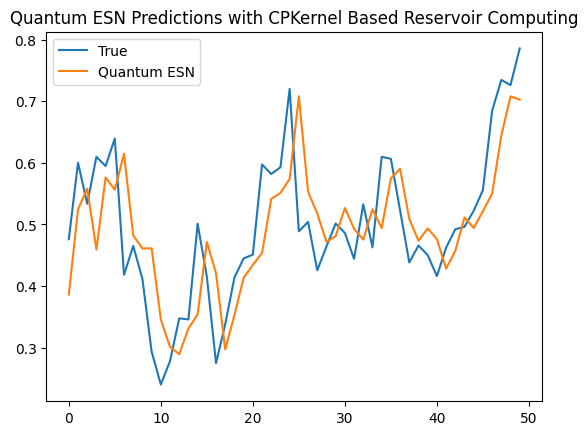

In [24]:
a = 0
b = 50
# Plot Predictions
plt.plot(y_test[a:a+b], label="True")
plt.plot(y_pred[a:a+b], label="Quantum ESN")
plt.title("Quantum ESN Predictions with CPKernel Based Reservoir Computing")
plt.legend()
plt.show()